In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_theme()

In [21]:
train_data = pd.read_csv('archive/train.csv')
val_data = pd.read_csv('archive/validation.csv')
test_data = pd.read_csv('archive/test.csv')

In [22]:
features = ['FreeTime', 'GoOut', 'StudyHours']
target = 'GPA'

In [23]:
train_x = train_data[features]
train_x['study_ratio']=train_x['StudyHours']/(train_x['FreeTime']+train_x['GoOut']+train_x['StudyHours'])
val_x = val_data[features]
val_x['study_ratio']=val_x['StudyHours']/(val_x['FreeTime']+val_x['GoOut']+val_x['StudyHours'])
test_x = test_data[features]
test_x['study_ratio']=test_x['StudyHours']/(test_x['FreeTime']+test_x['GoOut']+test_x['StudyHours'])

train_y = train_data[target]
val_y = val_data[target]
test_y = test_data[target]

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_x)
X_val_scaled = scaler.transform(val_x)
X_test_scaled = scaler.transform(test_x)

In [25]:
model = LinearRegression()
model.fit(X_train_scaled, train_y)

LinearRegression()

In [26]:
y_pred_train = model.predict(X_train_scaled)
y_pred_val = model.predict(X_val_scaled)
y_pred_test = model.predict(X_test_scaled)

In [28]:
coefficients = pd.DataFrame({
    'Feature': features+['study_ratio'],
    'Coefficient': model.coef_
})
coefficients['Absolute_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Absolute_Coefficient', ascending=False)

In [29]:
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nPerformance on {dataset_name} dataset:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# Evaluate model performance
evaluate_model(train_y, y_pred_train, "Training")
evaluate_model(val_y, y_pred_val, "Validation")
evaluate_model(test_y, y_pred_test, "Test")


Performance on Training dataset:
MSE: 0.1791
RMSE: 0.4232
R² Score: 0.1520

Performance on Validation dataset:
MSE: 0.1793
RMSE: 0.4234
R² Score: 0.1524

Performance on Test dataset:
MSE: 0.1791
RMSE: 0.4232
R² Score: 0.1518


In [30]:
train_x = train_data[features]
train_x['study_ratio']=train_x['StudyHours']/(train_x['FreeTime']+train_x['GoOut']+train_x['StudyHours'])
val_x = val_data[features]
val_x['study_ratio']=val_x['StudyHours']/(val_x['FreeTime']+val_x['GoOut']+val_x['StudyHours'])
test_x = test_data[features]
test_x['study_ratio']=test_x['StudyHours']/(test_x['FreeTime']+test_x['GoOut']+test_x['StudyHours'])

train_y = train_data[target]
val_y = val_data[target]
test_y = test_data[target]

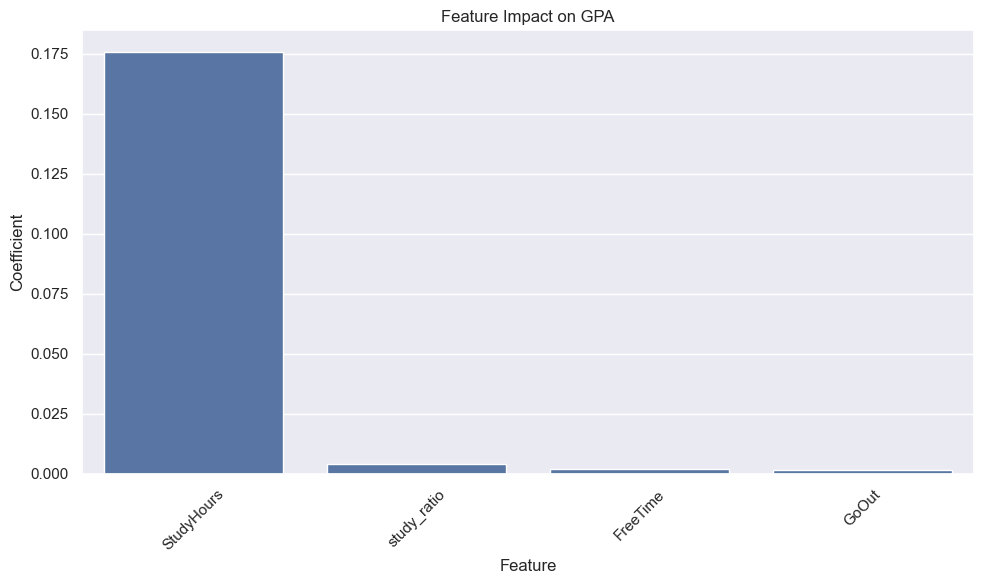

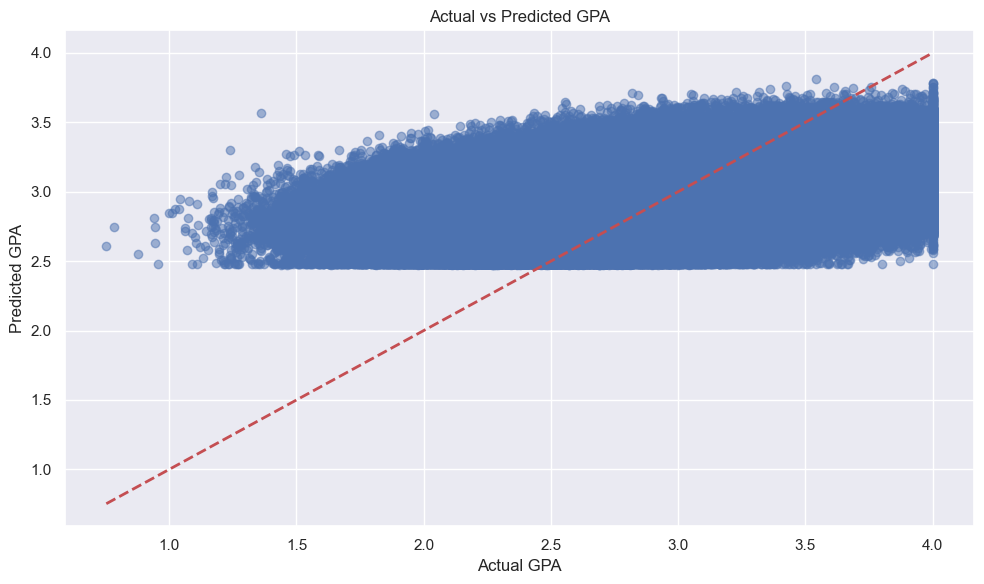

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Coefficient', data=coefficients)
plt.title('Feature Impact on GPA')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(test_y, y_pred_test, alpha=0.5)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], 'r--', lw=2)
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.title('Actual vs Predicted GPA')
plt.tight_layout()
plt.show()

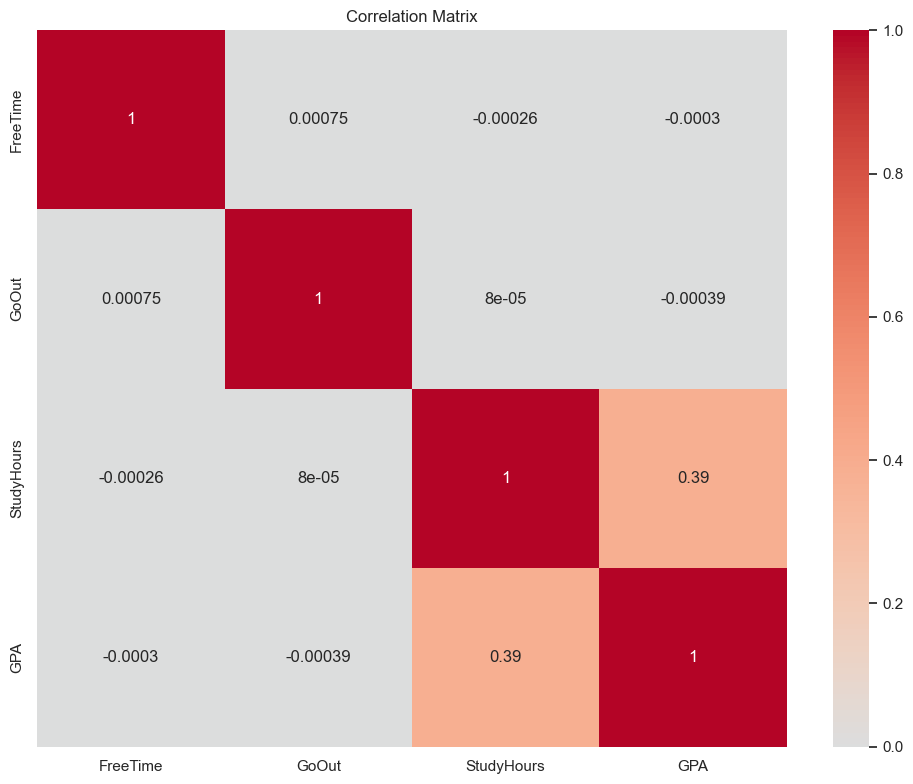


Correlation with GPA:
GPA           1.000000
StudyHours    0.389857
FreeTime     -0.000301
GoOut        -0.000385
Name: GPA, dtype: float64


In [11]:
# Calculate correlation matrix
correlation_matrix = train_data[features + [target]].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Print correlation with target
print("\nCorrelation with GPA:")
print(correlation_matrix[target].sort_values(ascending=False))

In [12]:
# Save results
results = {
    'model_params': {
        'intercept': model.intercept_,
        'coefficients': dict(zip(features, model.coef_))
    },
    'performance': {
        'train': {
            'mse': mean_squared_error(train_y, y_pred_train),
            'rmse': np.sqrt(mean_squared_error(train_y, y_pred_train)),
            'r2': r2_score(train_y, y_pred_train)
        },
        'validation': {
            'mse': mean_squared_error(val_y, y_pred_val),
            'rmse': np.sqrt(mean_squared_error(val_y, y_pred_val)),
            'r2': r2_score(val_y, y_pred_val)
        },
        'test': {
            'mse': mean_squared_error(test_y, y_pred_test),
            'rmse': np.sqrt(mean_squared_error(test_y, y_pred_test)),
            'r2': r2_score(test_y, y_pred_test)
        }
    },
    'feature_importance': coefficients.to_dict('records')
}

# Print final results
print("\n=== Final Analysis Results ===")
print("\nModel Coefficients:")
print(coefficients)
print("\nModel Intercept:", model.intercept_)


=== Final Analysis Results ===

Model Coefficients:
      Feature  Coefficient  Absolute_Coefficient
2  StudyHours     0.179144              0.179144
1       GoOut    -0.000191              0.000191
0    FreeTime    -0.000091              0.000091

Model Intercept: 2.9967429022722567
